In [ ]:
#Checking if it is connected to GPU
import torch
print(torch.cuda.is_available())

True


In [ ]:
#Adding drive content into notebook

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install sentence-transformers

In [ ]:
#imports file and deletes anything less then 20 charachters
#(answers that mention the seconds instead of thinking process)

import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/LLM_odev2_veriler.xlsx')

for i in range(len(df)):
  check_valid = len(str(df.loc[i, 'CosmosLLM düşünme süreci']))
  if check_valid <= 20:
    df.drop(i, inplace=True)

In [ ]:
#this changes the scores from text to numbers so that we can work with them later

score_change = {
    'çok iyi': 5,
    'iyi': 4,
    'orta': 3,
    'kötü': 2,
    'çok kötü': 1
}

def map_score(value):
    if isinstance(value, str):
        return score_change.get(value, value)
    return value

df['Değerlendirme Puanınız'] = df['Değerlendirme Puanınız'].apply(map_score)

print(df["Değerlendirme Puanınız"])

0        4
1        3
2        5
3        4
4        2
        ..
12129    3
12130    5
12131    3
12132    3
12133    2
Name: Değerlendirme Puanınız, Length: 10990, dtype: int64


In [ ]:
#changes name of colums
#S, D, C, score = df['Sorunuz'], df['CosmosLLM düşünme süreci'], df['CosmosLLM cevabı'], df['Değerlendirme Puanınız']
#print(df.columns)
df.columns = ['S', 'D', 'C', 'score']
print(df.columns)

Index(['S', 'D', 'C', 'score'], dtype='object')


In [ ]:
#creates configurations
config1 = df["S"].tolist()
config2 = df["D"].tolist()
config3 = df["C"].tolist()
config4 = (df["S"].astype(str) + "\n" + df["D"].astype(str)).tolist()
config5 = (df["D"].astype(str) + "\n" + df["C"].astype(str)).tolist()

In [ ]:
#this connects to huggingface using the secret token
from google.colab import userdata

import os
HF_TOKEN = userdata.get('HF_TOKEN')

if HF_TOKEN:
    os.environ['HF_TOKEN'] = HF_TOKEN
    print("HF_TOKEN successfully loaded from Colab secrets and set as environment variable.")
else:
    print("HF_TOKEN not found in Colab secrets. Please add it.")

HF_TOKEN successfully loaded from Colab secrets and set as environment variable.


In [ ]:
#this was nessary for the jina model only
!pip install --upgrade torchao

In [ ]:
#this is were it uses the models to find embeddings and saves them
import os
from sentence_transformers import SentenceTransformer
import torch
import numpy as np

model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-small",
    device="cuda")

config_str = [str(x) for x in config2]

embeddings = model.encode(config_str, batch_size=2, show_progress_bar=True)

output_dir = "/content/drive/MyDrive/AI_HW/"
os.makedirs(output_dir, exist_ok=True)
np.save(os.path.join(output_dir, "jina_config2.npy"), embeddings)

del model
torch.cuda.empty_cache()

In [ ]:
#here the 3 algorithms run for all 20 configurations after they are saved
#data is split and tested

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from pathlib import Path
import numpy as np
import pandas as pd

Algorithms = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

configurations = ["config1", "config2", "config3", "config4", "config5"]
models = ["ce_cosmos", "Qwen", "microsoft", "jina"]

embeddings_path = Path("/content/drive/MyDrive/AI_HW/")

final_output = []

Y = df["score"].values

for embeddings in models:
    for config in configurations:
        file_path = embeddings_path / f"{embeddings}_{config}.npy"

        if not file_path.exists():
            print(f"Warning: Embedding file not found for {embeddings} and {config}. Skipping.")
            continue

        X = np.load(file_path)

        if np.isnan(X).any() or np.isinf(X).any():
            print(f"Detected NaN or Inf values in embeddings for {embeddings} and {config}. Replacing with 0/finite max/min.")
            X = np.nan_to_num(X, nan=0.0, posinf=np.finfo(X.dtype).max, neginf=np.finfo(X.dtype).min)

        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1000, random_state=42)

        for algo, alg in Algorithms.items():
            alg.fit(X_train, Y_train)
            Y_pred = alg.predict(X_test)

            if np.isnan(Y_pred).any() or np.isinf(Y_pred).any():
                print(f"Warning: Detected NaN or Inf values in predictions for {embeddings} | {config} | {algo}. Replacing with 0/finite max/min.")
                Y_pred = np.nan_to_num(Y_pred, nan=0.0, posinf=np.finfo(Y_pred.dtype).max, neginf=np.finfo(Y_pred.dtype).min)

            final_output.append({
                "embedding_model": embeddings,
                "config": config,
                "algorithm": algo,
                "MSE": mean_squared_error(Y_test, Y_pred),
                "R2": r2_score(Y_test, Y_pred)
            })

            print(f"Done: {embeddings} | {config} | {algo} | MSE: {mean_squared_error(Y_test, Y_pred):.4f}")

output_df = pd.DataFrame(final_output)
pd.DataFrame(final_output).to_csv(
    "/content/drive/MyDrive/AI_HW/results.csv", index=False
)
print(output_df)

Done: ce_cosmos | config1 | Linear Regression | MSE: 1.3318
Done: ce_cosmos | config1 | Ridge | MSE: 1.2884
Done: ce_cosmos | config1 | Lasso | MSE: 1.2621
Done: ce_cosmos | config2 | Linear Regression | MSE: 1.3133
Done: ce_cosmos | config2 | Ridge | MSE: 1.2267
Done: ce_cosmos | config2 | Lasso | MSE: 1.2621
Done: ce_cosmos | config3 | Linear Regression | MSE: 1.2318
Done: ce_cosmos | config3 | Ridge | MSE: 1.1597
Done: ce_cosmos | config3 | Lasso | MSE: 1.2621
Done: ce_cosmos | config4 | Linear Regression | MSE: 1.3007
Done: ce_cosmos | config4 | Ridge | MSE: 1.2458
Done: ce_cosmos | config4 | Lasso | MSE: 1.2621
Done: ce_cosmos | config5 | Linear Regression | MSE: 1.3271
Done: ce_cosmos | config5 | Ridge | MSE: 1.2378
Done: ce_cosmos | config5 | Lasso | MSE: 1.2621
Done: Qwen | config1 | Linear Regression | MSE: 1.3231
Done: Qwen | config1 | Ridge | MSE: 1.2468
Done: Qwen | config1 | Lasso | MSE: 1.2621
Done: Qwen | config2 | Linear Regression | MSE: 1.3076
Done: Qwen | config2 | R

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:399: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Done: microsoft | config3 | Linear Regression | MSE: 16.9219
Done: microsoft | config3 | Ridge | MSE: 1.1343
Done: microsoft | config3 | Lasso | MSE: 1.2621
Done: microsoft | config4 | Linear Regression | MSE: 1.2891
Done: microsoft | config4 | Ridge | MSE: 1.2159
Done: microsoft | config4 | Lasso | MSE: 1.2621
Done: microsoft | config5 | Linear Regression | MSE: 1.2715
Done: microsoft | config5 | Ridge | MSE: 1.1917
Done: microsoft | config5 | Lasso | MSE: 1.2621
Done: jina | config1 | Linear Regression | MSE: 1.3193
Done: jina | config1 | Ridge | MSE: 1.2488
Done: jina | config1 | Lasso | MSE: 1.2621
Done: jina | config2 | Linear Regression | MSE: 1.2467
Done: jina | config2 | Ridge | MSE: 1.2463
Done: jina | config2 | Lasso | MSE: 1.2621
Done: jina | config3 | Linear Regression | MSE: 1.2174
Done: jina | config3 | Ridge | MSE: 1.2241
Done: jina | config3 | Lasso | MSE: 1.2621
Done: jina | config4 | Linear Regression | MSE: 1.2503
Done: jina | config4 | Ridge | MSE: 1.2505
Done: jina

In [ ]:
#was used to free up space
del model

import torch
import gc
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_summary())

In [ ]:
#also used to check space used
import torch
print(torch.cuda.memory_allocated() / 1e9, "GB used")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

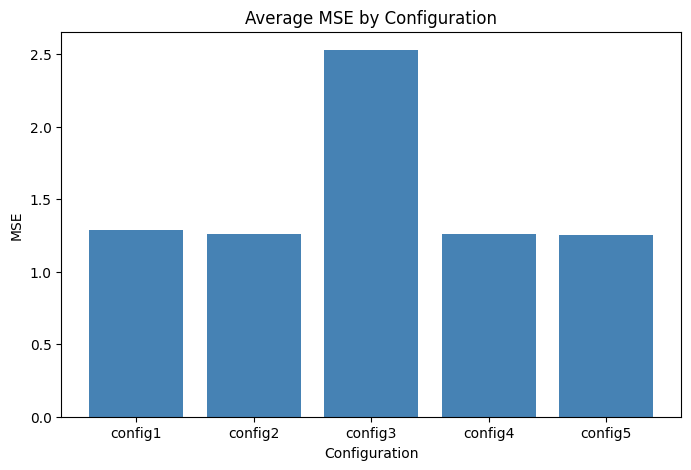

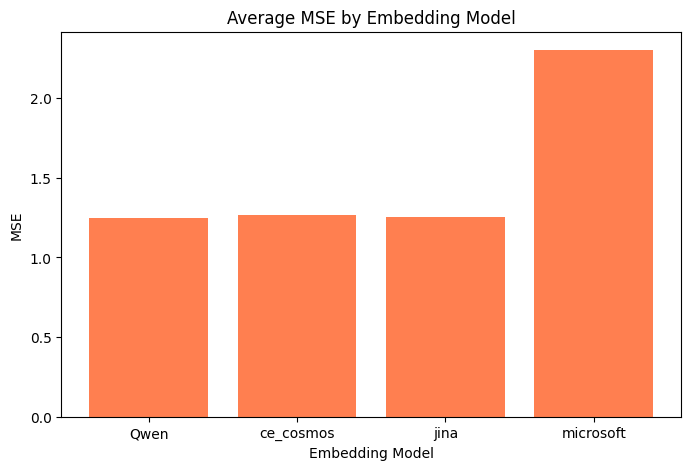

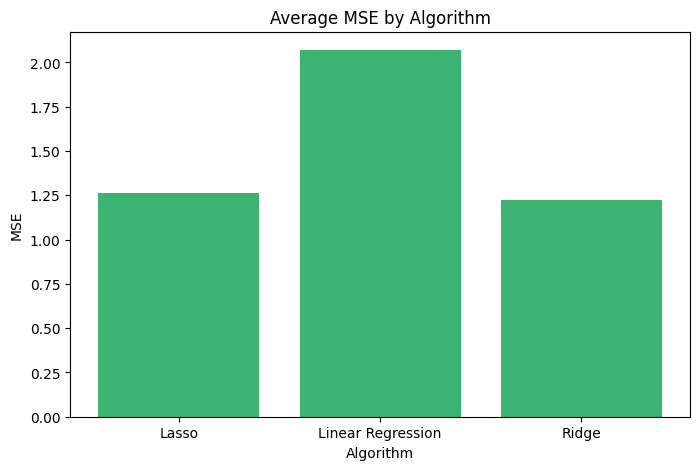

In [ ]:
#this saves the result in a graph
import matplotlib.pyplot as plt

output_df = pd.read_csv("/content/drive/MyDrive/AI_HW/results.csv")

# GRAPH 1 - average MSE by config
config_perf = output_df.groupby("config")["MSE"].mean()
plt.figure(figsize=(8,5))
plt.bar(config_perf.index, config_perf.values, color="steelblue")
plt.title("Average MSE by Configuration")
plt.xlabel("Configuration")
plt.ylabel("MSE")
plt.savefig("/content/drive/MyDrive/AI_HW/graph_configs.png")
plt.show()

# GRAPH 2 - average MSE by embedding model
model_perf = output_df.groupby("embedding_model")["MSE"].mean()
plt.figure(figsize=(8,5))
plt.bar(model_perf.index, model_perf.values, color="coral")
plt.title("Average MSE by Embedding Model")
plt.xlabel("Embedding Model")
plt.ylabel("MSE")
plt.savefig("/content/drive/MyDrive/AI_HW/graph_models.png")
plt.show()

# GRAPH 3 - average MSE by algorithm
alg_perf = output_df.groupby("algorithm")["MSE"].mean()
plt.figure(figsize=(8,5))
plt.bar(alg_perf.index, alg_perf.values, color="mediumseagreen")
plt.title("Average MSE by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("MSE")
plt.savefig("/content/drive/MyDrive/AI_HW/graph_algorithms.png")
plt.show()

In [ ]:
#here the output is printed

output_df = pd.read_csv("/content/drive/MyDrive/AI_HW/results.csv")


print(output_df.groupby("config")[["MSE","R2"]].mean().round(4))
print(output_df.groupby("embedding_model")[["MSE","R2"]].mean().round(4))
print(output_df.groupby("algorithm")[["MSE","R2"]].mean().round(4))

            MSE      R2
config                 
config1  1.2903 -0.0231
config2  1.2598  0.0010
config3  2.5294 -1.0053
config4  1.2597  0.0012
config5  1.2509  0.0081
                    MSE      R2
embedding_model                
Qwen             1.2507  0.0083
ce_cosmos        1.2649 -0.0030
jina             1.2541  0.0056
microsoft        2.3023 -0.8254
                      MSE      R2
algorithm                        
Lasso              1.2621 -0.0008
Linear Regression  2.0699 -0.6411
Ridge              1.2220  0.0310
